In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans as TextKMeans

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
stars = pd.read_csv("Stars.csv")

# Display first rows
stars.head()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type,Star category,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,0,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,0,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,0,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,0,Brown Dwarf,Red,M


In [3]:
# Select numerical columns
numeric_features = stars.select_dtypes(include=np.number)

numeric_features.head()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type
0,3068,0.002400,0.1700,16.12,0
1,3042,0.000500,0.1542,16.60,0
2,2600,0.000300,0.1020,18.70,0
3,2800,0.000200,0.1600,16.65,0
4,1939,0.000138,0.1030,20.06,0


In [4]:
numeric_features = numeric_features.fillna(
    numeric_features.mean()
)

In [5]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_features)

scaled_data[:5]

array([[-0.7793821 , -0.59862356, -0.45920992,  1.11674535, -1.46385011],
       [-0.78210961, -0.59862357, -0.45924053,  1.16241376, -1.46385011],
       [-0.82847728, -0.59862357, -0.45934168,  1.36221308, -1.46385011],
       [-0.80749644, -0.59862357, -0.45922929,  1.16717089, -1.46385011],
       [-0.89781898, -0.59862357, -0.45933974,  1.49160692, -1.46385011]])

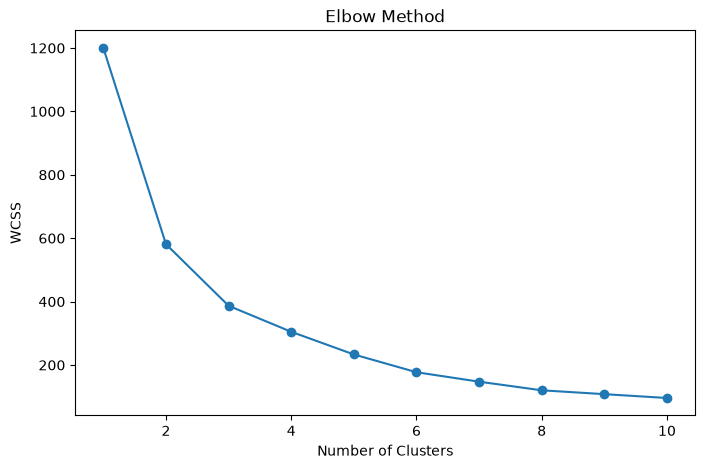

In [6]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

stars["Cluster"] = clusters

stars.head()

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type,Star category,Star color,Spectral Class,Cluster
0,3068,0.002400,0.1700,16.12,0,Brown Dwarf,Red,M,3
1,3042,0.000500,0.1542,16.60,0,Brown Dwarf,Red,M,3
2,2600,0.000300,0.1020,18.70,0,Brown Dwarf,Red,M,3
3,2800,0.000200,0.1600,16.65,0,Brown Dwarf,Red,M,3
4,1939,0.000138,0.1030,20.06,0,Brown Dwarf,Red,M,3


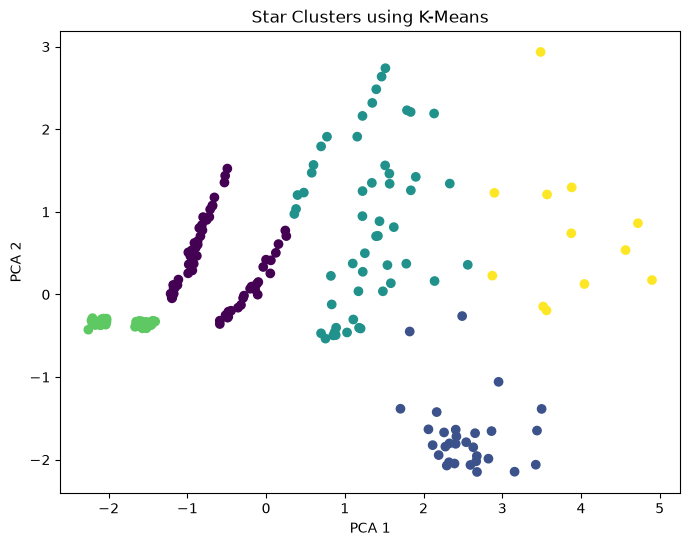

In [8]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Star Clusters using K-Means")

plt.show()

In [10]:
stars.to_csv(
    "Stars_KMeans_Result.csv",
    index=False
)